Name : Faheema Mohamed Maideen
Data set: New york city airbnb listing 
Description: This dataset describes the listing activity and metrics in NYC, NY for 2019 also, this data file includes all needed information to find out more about hosts, geographical availability, necessary metrics to make predictions and draw conclusions.
I used Python version 3.31.9






In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("AB_NYC_2019.csv")
df.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
def remove_duplicates(df):
    """
    Remove duplicate rows from a DataFrame.

    Parameters:
        df (pd.DataFrame): The input dataset.

    Returns:
        pd.DataFrame: A new DataFrame with duplicate rows removed.
    
    Example:
        df = remove_duplicates(df)
    """
    before = len(df)
    df_cleaned = df.drop_duplicates()
    after = len(df_cleaned)
    print(f"Removed {before - after} duplicate rows ({before} → {after})")
    return df_cleaned.reset_index(drop=True)

def normalize_column_names(df):
    """
    Standardize column names to lowercase with underscores.
    Removes leading/trailing spaces and replaces spaces with underscores.

    Parameters:
        df (pd.DataFrame): The input dataset.

    Returns:
        pd.DataFrame: A new DataFrame with cleaned column names.

    Example:
        df = normalize_column_names(df)
        # "First Name " → "first_name"
        # "AGE"         → "age"
    """
    df_cleaned = df.copy()
    df_cleaned.columns = (
        df_cleaned.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )
    print(f"Columns renamed: {list(df.columns)} → {list(df_cleaned.columns)}")
    return df_cleaned

In [7]:


def summary_statistics(df):
    """
    Print a full dataset overview: shape, dtypes, missing values,
    and descriptive statistics for all columns.

    Parameters:
        df (pd.DataFrame): The input dataset.

    Returns:
        dict: A summary dictionary with shape, missing, and describe.

    Example:
        summary_statistics(df)
    """
    print("=" * 60)
    print("📊  DATASET SUMMARY")
    print("=" * 60)

    print(f"\n🔷 Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")

    print("\n🔷 Data Types:")
    print(df.dtypes.to_string())

    print("\n🔷 Missing Values:")
    missing       = df.isnull().sum()
    missing_pct   = (missing / len(df) * 100).round(2)
    missing_df    = pd.DataFrame({"count": missing, "percent (%)": missing_pct})
    missing_found = missing_df[missing_df["count"] > 0]
    if missing_found.empty:
        print("  None found ✅")
    else:
        print(missing_found.sort_values("count", ascending=False).to_string())

    print("\n🔷 Descriptive Statistics:")
    print(df.describe(include="all").round(2).to_string())

    print("\n🔷 Sample Rows (first 5):")
    print(df.head().to_string())
    print("=" * 60)

    return {
        "shape":   df.shape,
        "missing": missing_found,
        "describe": df.describe(include="all"),
    }


def grouped_analysis(df, group_col, agg_col, agg_func="mean", top_n=10, plot=True):
    """
    Group the dataset by a categorical column and aggregate a numeric column.
    Optionally renders a horizontal bar chart.

    Parameters:
        df       (pd.DataFrame): The input dataset.
        group_col (str)        : Column to group by  (e.g. 'neighbourhood_group').
        agg_col   (str)        : Column to aggregate (e.g. 'price').
        agg_func  (str)        : 'mean' | 'sum' | 'count' | 'median' | 'max' | 'min'.
        top_n     (int)        : Show only the top N groups. Default 10.
        plot      (bool)       : Whether to render a bar chart. Default True.

    Returns:
        pd.DataFrame: Grouped and sorted results.

    Example:
        grouped_analysis(df, 'neighbourhood_group', 'price', agg_func='mean')
        grouped_analysis(df, 'room_type', 'price', agg_func='median')
    """
    print("=" * 60)
    print(f"📊  GROUPED ANALYSIS")
    print(f"    {agg_func.upper()}  of  '{agg_col}'  by  '{group_col}'")
    print("=" * 60)

    result_col = f"{agg_func}_{agg_col}"
    grouped = (
        df.groupby(group_col)[agg_col]
        .agg(agg_func)
        .reset_index()
        .rename(columns={agg_col: result_col})
        .sort_values(result_col, ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    print(grouped.to_string(index=False))

    if plot:
        fig, ax = plt.subplots(figsize=(9, max(3, len(grouped) * 0.55)))
        bars = ax.barh(
            grouped[group_col][::-1],
            grouped[result_col][::-1],
            color="#7F77DD",
            edgecolor="none",
        )
        ax.bar_label(bars, fmt="%.1f", padding=4, fontsize=9)
        ax.set_xlabel(result_col, fontsize=10)
        ax.set_title(
            f"{agg_func.capitalize()} of '{agg_col}' by '{group_col}'",
            fontsize=11, pad=10
        )
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        plt.show()

    return grouped


def correlation_check(df, method="pearson", threshold=0.3, plot=True):
    """
    Compute and optionally visualise the correlation matrix for numeric columns.
    Also prints all strongly correlated pairs above the given threshold.

    Parameters:
        df        (pd.DataFrame): The input dataset.
        method    (str)         : 'pearson' | 'spearman' | 'kendall'. Default 'pearson'.
        threshold (float)       : Minimum |r| to flag as a strong pair. Default 0.3.
        plot      (bool)        : Whether to render a heatmap. Default True.

    Returns:
        pd.DataFrame: Full correlation matrix.

    Example:
        correlation_check(df, method='spearman', threshold=0.4)
    """
    print("=" * 60)
    print(f"📊  CORRELATION MATRIX  ({method.upper()})")
    print("=" * 60)

    numeric_df  = df.select_dtypes(include=np.number)
    corr_matrix = numeric_df.corr(method=method).round(2)

    print(corr_matrix.to_string())

    # Strongest pairs
    upper_tri = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    pairs = (
        upper_tri.stack()
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "r"})
    )
    strong = (
        pairs[pairs["r"].abs() >= threshold]
        .sort_values("r", key=abs, ascending=False)
    )

    print(f"\n🔷 Pairs with |r| ≥ {threshold}:")
    if strong.empty:
        print("  None found")
    else:
        print(strong.to_string(index=False))

    if plot:
        fig, ax = plt.subplots(figsize=(10, 7))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(
            corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            linewidths=0.4,
            ax=ax,
            cbar_kws={"shrink": 0.8},
        )
        ax.set_title(
            f"Correlation Matrix ({method.capitalize()})",
            fontsize=11, pad=12
        )
        plt.tight_layout()
        plt.show()

    return corr_matrix


def filtered_view(df, column, condition, value, plot_col=None):
    """
    Filter the dataset on a condition and print a summary.
    Optionally plot the distribution of any numeric column in the filtered subset.

    Parameters:
        df        (pd.DataFrame): The input dataset.
        column    (str)         : Column to filter on.
        condition (str)         : '>' | '<' | '==' | '>=' | '<=' | '!=' | 'contains'.
        value                   : Value to compare against.
        plot_col  (str | None)  : If given, plot that column's distribution after filtering.

    Returns:
        pd.DataFrame: Filtered subset.

    Example:
        filtered_view(df, 'price', '>', 500)
        filtered_view(df, 'neighbourhood_group', '==', 'Manhattan', plot_col='price')
        filtered_view(df, 'name', 'contains', 'cozy')
    """
    print("=" * 60)
    print(f"📊  FILTERED VIEW :  {column}  {condition}  {repr(value)}")
    print("=" * 60)

    ops = {
        ">":        df[column] > value,
        "<":        df[column] < value,
        "==":       df[column] == value,
        ">=":       df[column] >= value,
        "<=":       df[column] <= value,
        "!=":       df[column] != value,
        "contains": df[column].astype(str).str.contains(str(value), case=False, na=False),
    }
    if condition not in ops:
        raise ValueError(f"condition must be one of {list(ops.keys())}")

    mask        = ops[condition]
    df_filtered = df[mask].reset_index(drop=True)
    pct         = len(df_filtered) / len(df) * 100

    print(f"  Matched : {len(df_filtered):,} / {len(df):,} rows ({pct:.1f}%)")
    print(f"\n🔷 Descriptive stats for filtered subset:")
    print(df_filtered.describe().round(2).to_string())

    print(f"\n🔷 Sample rows:")
    print(df_filtered.head(5).to_string())

    if plot_col and pd.api.types.is_numeric_dtype(df_filtered[plot_col]):
        fig, ax = plt.subplots(figsize=(8, 3.5))
        ax.hist(df_filtered[plot_col].dropna(), bins=40, color="#1D9E75", edgecolor="none")
        ax.set_xlabel(plot_col, fontsize=10)
        ax.set_ylabel("Count", fontsize=10)
        ax.set_title(
            f"Distribution of '{plot_col}'  where {column} {condition} {repr(value)}",
            fontsize=10
        )
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        plt.show()

    return df_filtered


def run_full_eda(df, group_col=None, agg_col=None):
    """
    Run the complete EDA pipeline in one call:
        1. Summary statistics
        2. Grouped analysis     (if group_col and agg_col are provided)
        3. Correlation check
        4. Missing value report (already inside summary_statistics)

    Parameters:
        df        (pd.DataFrame): The input dataset.
        group_col (str | None)  : Column to group by for grouped analysis.
        agg_col   (str | None)  : Column to aggregate for grouped analysis.

    Returns:
        dict: Keys 'summary', 'grouped', 'correlation'.

    Example:
        results = run_full_eda(df, group_col='neighbourhood_group', agg_col='price')
    """
    results = {}

    results["summary"] = summary_statistics(df)

    if group_col and agg_col:
        results["grouped"] = grouped_analysis(df, group_col, agg_col)
    else:
        results["grouped"] = None

    results["correlation"] = correlation_check(df)

    return results

📊  DATASET SUMMARY

🔷 Shape : 48,895 rows × 16 columns

🔷 Data Types:
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64

🔷 Missing Values:
                   count  percent (%)
last_review        10052        20.56
reviews_per_month  10052        20.56
host_name             21         0.04
name                  16         0.03

🔷 Descriptive Statistics:
                 id   

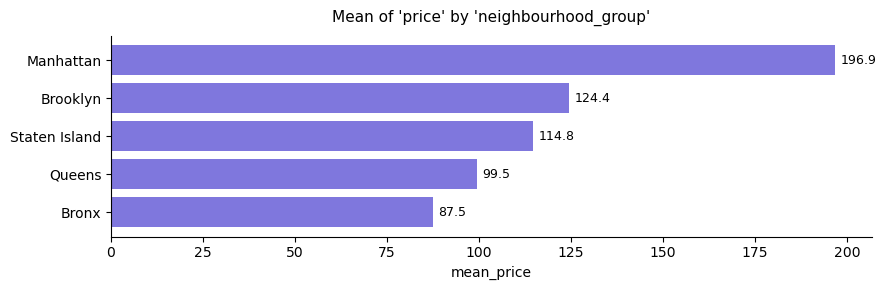

📊  CORRELATION MATRIX  (PEARSON)
                                  id  host_id  latitude  longitude  price  minimum_nights  number_of_reviews  reviews_per_month  calculated_host_listings_count  availability_365
id                              1.00     0.59     -0.00       0.09   0.01           -0.01              -0.32               0.29                            0.13              0.09
host_id                         0.59     1.00      0.02       0.13   0.02           -0.02              -0.14               0.30                            0.15              0.20
latitude                       -0.00     0.02      1.00       0.08   0.03            0.02              -0.02              -0.01                            0.02             -0.01
longitude                       0.09     0.13      0.08       1.00  -0.15           -0.06               0.06               0.15                           -0.11              0.08
price                           0.01     0.02      0.03      -0.15   1.00    

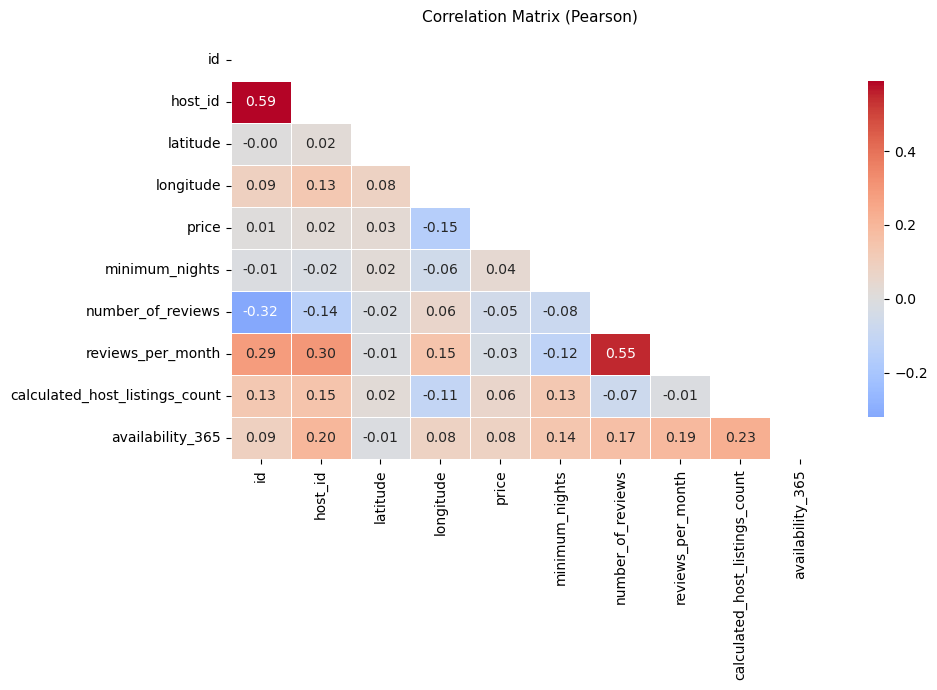

📊  GROUPED ANALYSIS
    MEDIAN  of  'price'  by  'room_type'
      room_type  median_price
Entire home/apt         160.0
   Private room          70.0
    Shared room          45.0


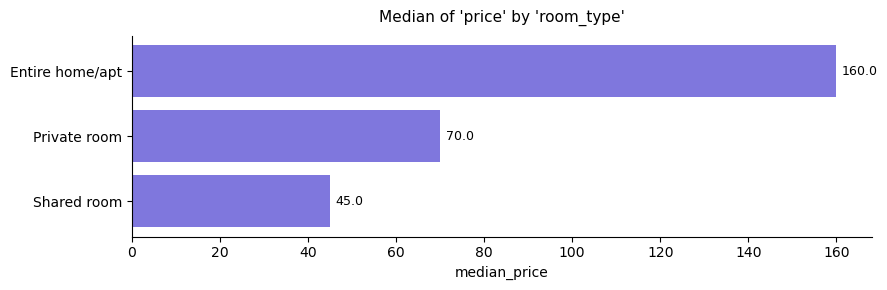

📊  GROUPED ANALYSIS
    COUNT  of  'price'  by  'neighbourhood_group'
neighbourhood_group  count_price
          Manhattan        21661
           Brooklyn        20104
             Queens         5666
              Bronx         1091
      Staten Island          373


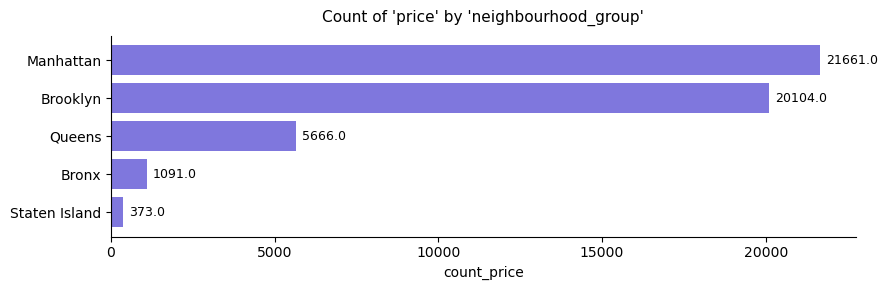

📊  GROUPED ANALYSIS
    MEAN  of  'price'  by  'neighbourhood'
    neighbourhood  mean_price
   Fort Wadsworth  800.000000
          Woodrow  700.000000
          Tribeca  490.638418
         Sea Gate  487.857143
        Riverdale  442.090909
     Prince's Bay  409.500000
Battery Park City  367.557143
Flatiron District  341.925000
    Randall Manor  336.000000
             NoHo  295.717949


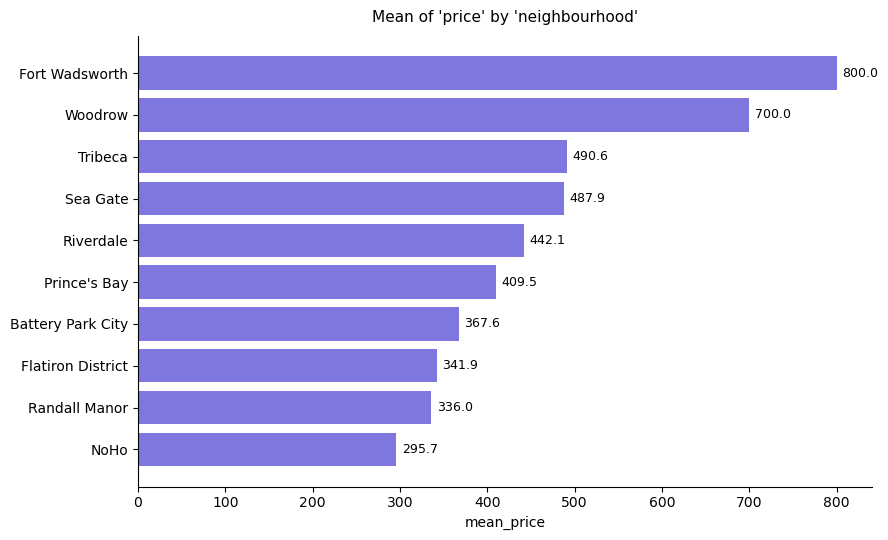

📊  CORRELATION MATRIX  (SPEARMAN)
                                  id  host_id  latitude  longitude  price  minimum_nights  number_of_reviews  reviews_per_month  calculated_host_listings_count  availability_365
id                              1.00     0.56      0.00       0.07  -0.02           -0.06              -0.31               0.36                            0.14              0.17
host_id                         0.56     1.00      0.05       0.11  -0.07           -0.13              -0.13               0.27                            0.15              0.17
latitude                        0.00     0.05      1.00       0.04   0.14            0.02              -0.04              -0.02                            0.00             -0.01
longitude                       0.07     0.11      0.04       1.00  -0.44           -0.12               0.08               0.12                            0.06              0.07
price                          -0.02    -0.07      0.14      -0.44   1.00   

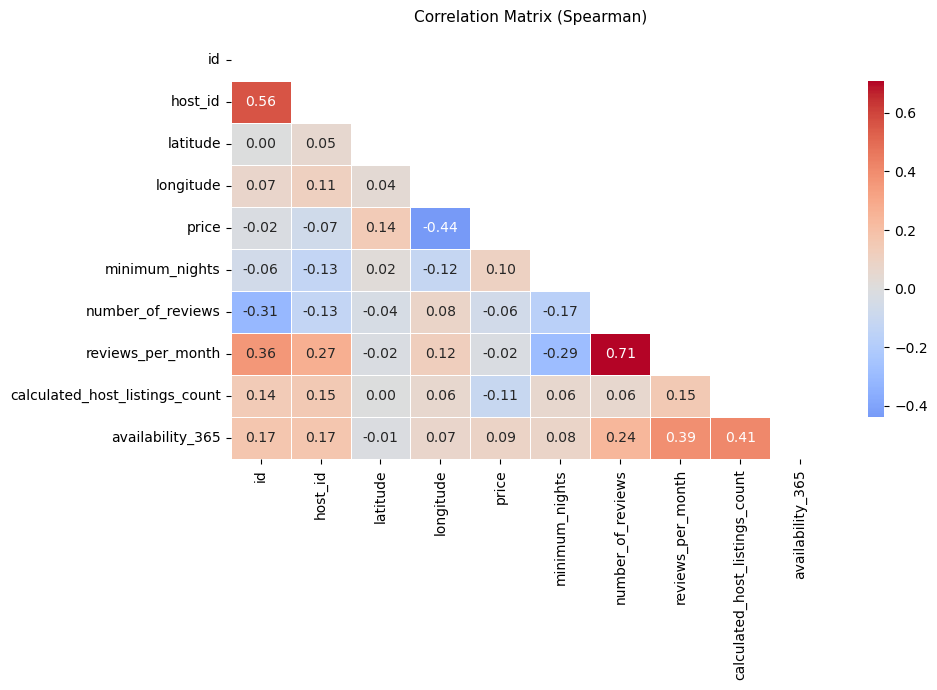

📊  FILTERED VIEW :  neighbourhood_group  ==  'Manhattan'
  Matched : 21,661 / 48,895 rows (44.3%)

🔷 Descriptive stats for filtered subset:
                id       host_id  latitude  longitude     price  minimum_nights  number_of_reviews  reviews_per_month  calculated_host_listings_count  availability_365
count     21661.00  2.166100e+04  21661.00   21661.00  21661.00        21661.00           21661.00           16632.00                        21661.00          21661.00
mean   18774939.21  6.783062e+07     40.77     -73.97    196.88            8.58              20.99               1.27                           12.79            111.98
std    11167932.02  7.936435e+07      0.04       0.02    291.38           24.05              42.57               1.63                           48.23            132.68
min        2595.00  2.845000e+03     40.70     -74.02      0.00            1.00               0.00               0.01                            1.00              0.00
25%     9162161.00  

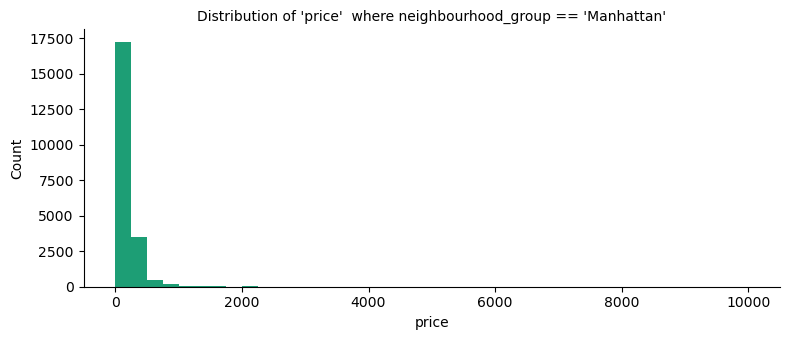

📊  FILTERED VIEW :  price  >  500
  Matched : 1,044 / 48,895 rows (2.1%)

🔷 Descriptive stats for filtered subset:
                id       host_id  latitude  longitude     price  minimum_nights  number_of_reviews  reviews_per_month  calculated_host_listings_count  availability_365
count      1044.00  1.044000e+03   1044.00    1044.00   1044.00         1044.00            1044.00             622.00                         1044.00           1044.00
mean   20650159.47  8.858471e+07     40.74     -73.98   1123.95            9.25              10.80               1.12                           10.24            184.95
std    11683304.37  8.971896e+07      0.04       0.03   1176.04           25.48              26.81               1.31                           40.73            140.67
min       19601.00  8.730000e+03     40.53     -74.20    503.00            1.00               0.00               0.01                            1.00              0.00
25%    10384563.25  1.046189e+07     40.72   

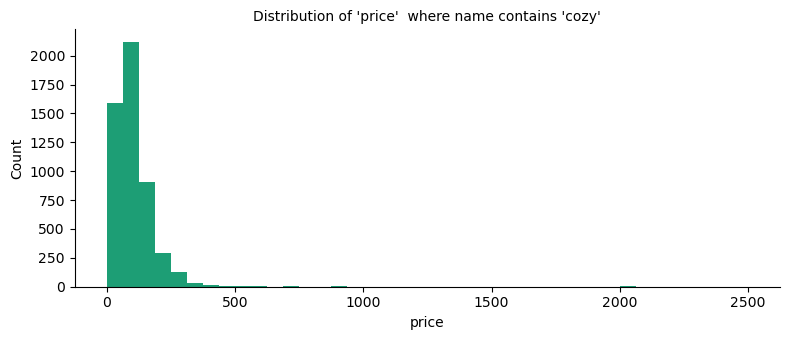

📊  FILTERED VIEW :  availability_365  ==  0
  Matched : 17,533 / 48,895 rows (35.9%)

🔷 Descriptive stats for filtered subset:
                id       host_id  latitude  longitude     price  minimum_nights  number_of_reviews  reviews_per_month  calculated_host_listings_count  availability_365
count     17533.00  1.753300e+04  17533.00   17533.00  17533.00        17533.00           17533.00           12688.00                        17533.00           17533.0
mean   15461716.41  4.288263e+07     40.73     -73.96    136.03            4.69               7.93               0.47                            1.44               0.0
std     8983374.61  5.314493e+07      0.05       0.03    211.23           12.18              19.96               0.85                            3.79               0.0
min        5022.00  2.438000e+03     40.52     -74.20      0.00            1.00               0.00               0.01                            1.00               0.0
25%     8011605.00  6.989380e+06 

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
1,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
2,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
3,6090,West Village Nest - Superhost,11975,Alina,Manhattan,West Village,40.73530,-74.00525,Entire home/apt,120,90,27,2018-10-31,0.22,1,0
4,7801,Sweet and Spacious Brooklyn Loft,21207,Chaya,Brooklyn,Williamsburg,40.71842,-73.95718,Entire home/apt,299,3,9,2011-12-28,0.07,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17528,36313048,Sunny room with private entrance in shared home,16883913,Tiffany,Queens,Ridgewood,40.69919,-73.89902,Private room,45,1,0,NaN,NaN,1,0
17529,36410519,Sunlight charming apt. in the heart of Brooklyn,121384174,Luciana Paula,Brooklyn,Park Slope,40.66716,-73.98101,Entire home/apt,111,8,0,NaN,NaN,1,0
17530,36419441,Murray Hill Masterpiece,273824202,David,Manhattan,Murray Hill,40.74404,-73.97239,Entire home/apt,129,2,0,NaN,NaN,1,0
17531,36420725,"Sunnyside, Queens 15 Mins to Midtown Clean & C...",19990280,Brandon,Queens,Sunnyside,40.74719,-73.91919,Private room,46,1,0,NaN,NaN,1,0


In [8]:
df = pd.read_csv("AB_NYC_2019.csv")

# ── 1. Full pipeline in one call ──────────────────────────────
results = run_full_eda(df, group_col="neighbourhood_group", agg_col="price")

# ── 2. Grouped views ──────────────────────────────────────────
grouped_analysis(df, "room_type",            "price",  agg_func="median")
grouped_analysis(df, "neighbourhood_group",  "price",  agg_func="count",  top_n=5)
grouped_analysis(df, "neighbourhood",        "price",  agg_func="mean",   top_n=10)

# ── 3. Correlation with spearman (handles skewed price data) ──
correlation_check(df, method="spearman", threshold=0.3)

# ── 4. Filtered views ─────────────────────────────────────────
filtered_view(df, "neighbourhood_group", "==", "Manhattan",  plot_col="price")
filtered_view(df, "price",              ">",  500)
filtered_view(df, "name",              "contains", "cozy",  plot_col="price")
filtered_view(df, "availability_365",  "==",  0)          # inactive listings

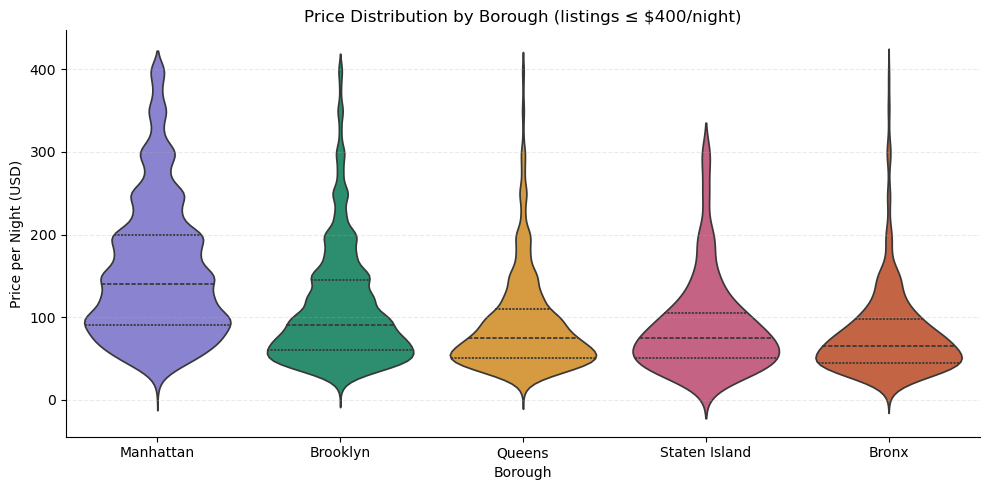

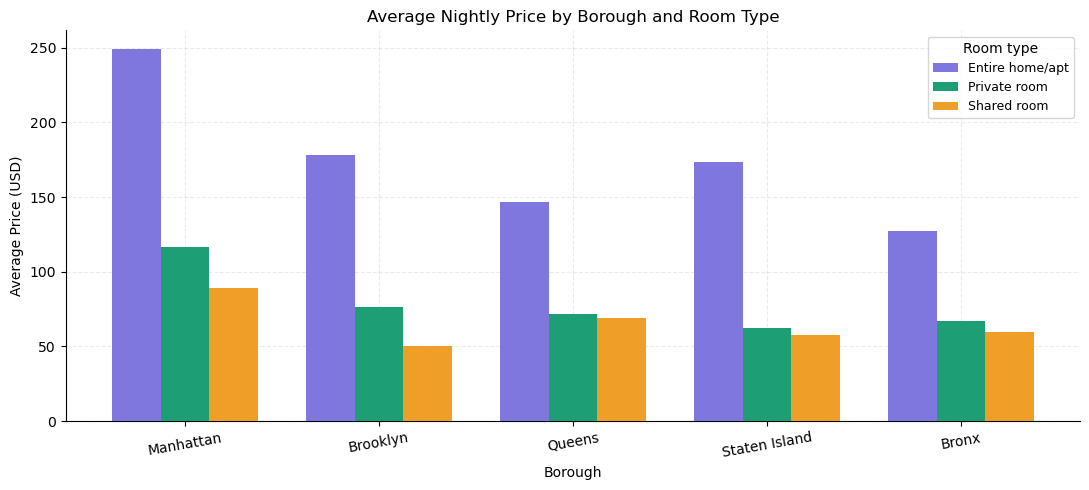

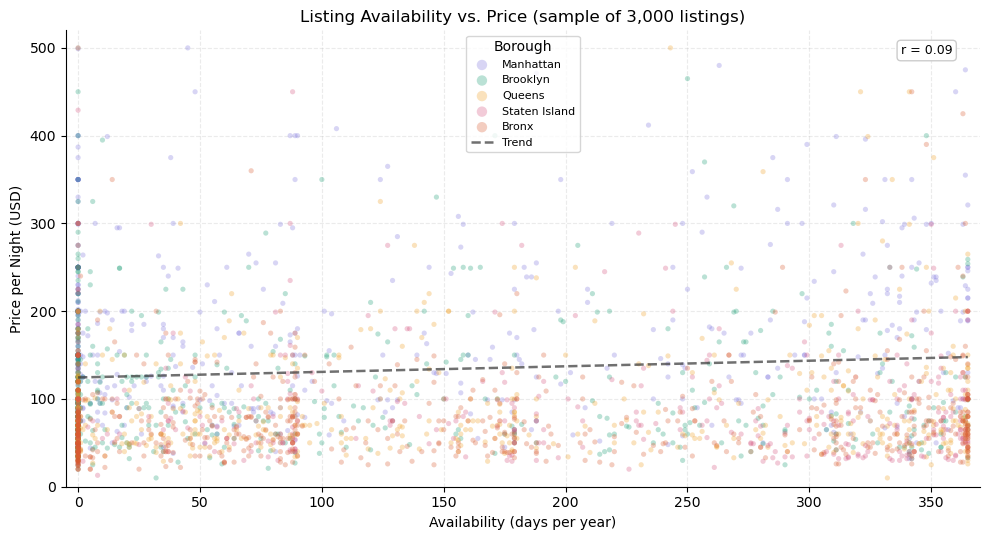

In [16]:

# ─── Shared config ────────────────────────────────────────────
boroughs = ['Manhattan', 'Brooklyn', 'Queens', 'Staten Island', 'Bronx']

pal = {
    'Manhattan':     '#7F77DD',
    'Brooklyn':      '#1D9E75',
    'Queens':        '#EF9F27',
    'Bronx':         '#D85A30',
    'Staten Island': '#D4537E',
}

plt.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'grid.linestyle':    '--',
})


# ════════════════════════════════════════════════════════════════
# VIZ 1 — Violin Plot: Price Distribution by Borough
# ════════════════════════════════════════════════════════════════

df_violin = df[(df['price'] > 0) & (df['price'] <= 400)]   # ✅ filter outliers

fig1, ax = plt.subplots(figsize=(10, 5))                    # ✅ ax defined

sns.violinplot(
    data=df_violin,
    x='neighbourhood_group',
    y='price',
    order=boroughs,                  # ✅ defined above
    hue='neighbourhood_group',       # ✅ required for palette in seaborn v0.13+
    palette=pal,                     # ✅ defined above
    inner='quartile',
    legend=False,
    ax=ax                            # ✅ defined above
)

ax.set_title('Price Distribution by Borough (listings ≤ $400/night)')
ax.set_xlabel('Borough')
ax.set_ylabel('Price per Night (USD)')
plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════════════════════
# VIZ 2 — Grouped Bar: Avg Price by Borough & Room Type
# ════════════════════════════════════════════════════════════════

grouped = (
    df.groupby(['neighbourhood_group', 'room_type'])['price']
    .mean()
    .unstack()
    .loc[boroughs]                   # ✅ reorder rows to match boroughs list
)

rooms       = ['Entire home/apt', 'Private room', 'Shared room']   # ✅ room list
room_colors = ['#7F77DD', '#1D9E75', '#EF9F27']                    # ✅ colors per room
x           = np.arange(len(boroughs))                             # ✅ x positions [0,1,2,3,4]
width       = 0.25                                                  # ✅ bar width
offsets     = [-width, 0, width]                                    # ✅ left / center / right

fig2, ax = plt.subplots(figsize=(11, 5))                            # ✅ fresh ax

for room, color, offset in zip(rooms, room_colors, offsets):       # ✅ offset defined in loop
    ax.bar(
        x + offset,          # ✅ x and offset both defined
        grouped[room],
        width,               # ✅ width defined
        label=room,
        color=color,
        edgecolor='none',
        zorder=3
    )

ax.set_title('Average Nightly Price by Borough and Room Type')
ax.set_xlabel('Borough')
ax.set_ylabel('Average Price (USD)')
ax.set_xticks(x)
ax.set_xticklabels(boroughs, rotation=10)
ax.legend(title='Room type', fontsize=9)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════════════════════
# VIZ 3 — Scatter: Availability vs Price (coloured by borough)
# ════════════════════════════════════════════════════════════════

df_scatter = df[(df['price'] > 0) & (df['price'] <= 500)]   # ✅ filtered data

# ✅ Sample per borough so the plot isn't overwhelmed
frames = []
for b in boroughs:
    sub = df_scatter[df_scatter['neighbourhood_group'] == b]
    frames.append(sub.sample(min(600, len(sub)), random_state=42))
sample = pd.concat(frames)

fig3, ax = plt.subplots(figsize=(10, 5.5))                   # ✅ fresh ax

for borough in boroughs:
    sub   = sample[sample['neighbourhood_group'] == borough]
    color = pal[borough]                                     # ✅ color pulled from pal dict
    ax.scatter(
        sub['availability_365'],
        sub['price'],
        c=color,             # ✅ color defined per loop iteration
        alpha=0.30,
        s=14,
        label=borough,
        edgecolors='none',
        zorder=2
    )

# ✅ Trend line
z  = np.polyfit(df_scatter['availability_365'], df_scatter['price'], 1)
xs = np.linspace(0, 365, 200)                                # ✅ xs defined
ax.plot(xs, np.poly1d(z)(xs), linestyle='--', color='#333',
        linewidth=1.8, alpha=0.7, label='Trend')

# ✅ Correlation annotation
r = df_scatter[['availability_365', 'price']].corr().iloc[0, 1]
ax.text(0.97, 0.97, f'r = {r:.2f}', transform=ax.transAxes,
        ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#ccc'))

ax.set_title('Listing Availability vs. Price (sample of 3,000 listings)')
ax.set_xlabel('Availability (days per year)')
ax.set_ylabel('Price per Night (USD)')
ax.set_xlim(-5, 370)
ax.set_ylim(0, 520)
ax.legend(title='Borough', fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()

1. What I Learned from the Dataset:

About the data :

Real-world datasets are never perfectly clean:
    Even a well-known public dataset like this had missing values, $0 price listings, and extreme outliers up to $10,000/night that needed handling before any analysis
Missing values don't always mean "bad data" :
     The 10,052 missing last_review entries simply meant those listings had never been reviewed, so filling with 0 was smarter than dropping 20% of the data.
A single dataset can answer many different questions depending on how we slice and group it:
    borough, room type, neighbourhood, and availability all tell completely different stories

About NYC Airbnb market:

The Airbnb market in NYC is heavily concentrated:
    Manhattan and Brooklyn alone hold 85% of all listings, meaning the other three boroughs are dramatically underrepresented.
Price is not determined by a single factor:
    It is shaped by a combination of location, room type, and neighbourhood prestige working together
Most listings are either entirely unavailable (0 days) or widely available (365 days): 
    Very few fall in the middle, suggesting hosts are either fully active or completely inactive


2. Interesting Patterns and Insights:

Pattern 1 — The Manhattan premium is real but uneven:

    Manhattan's average price ($197) is 2.25× the Bronx ($88), but the gap is even larger for entire homes ($249 Manhattan vs $128 Bronx). For shared rooms the gap narrows significantly ($89 vs $60), suggesting budget travellers can partially escape the Manhattan premium by choosing shared rooms.

Pattern 2 — Brooklyn is the volume king, not Manhattan:

    Despite Manhattan having higher prices, Brooklyn has almost as many listings (20,104 vs 21,661). Williamsburg and Bedford-Stuyvesant alone account for nearly 8,000 listings — more than Queens, Bronx, and Staten Island combined.


3. Limitations and Assumptions:

Limitations:
    
    LimitationImpactData is from 2019 onlyCannot reflect post-COVID changes in the marketNo booking or revenue dataCannot calculate actual earnings per listingNo guest review scoresCannot measure quality, only quantity of reviewsNo cancellation dataCannot tell if a listing is reliable or notPrice is listed price, not booked priceActual transaction prices may differ significantly

Assumptions made during analysis:

    * Listings with price = 0 were treated as data errors and excluded.
    * Missing last_review and reviews_per_month were assumed to mean zero reviews, not truly missing data.
    * Listings priced above $1,000 were treated as outliers and excluded from distribution plots.
    * Number of reviews was used as a rough proxy for booking activity, though this is imperfect.


4. Surprising and Unclear Things:

Surprising:

    $10,000/night listings exist — 239 listings were priced above $1,000 and the maximum was 
    $10,000. It is unclear if these are genuine luxury listings, pricing errors, or placeholder prices set by hosts who don't actually want bookings

Staten Island is almost invisible :
    
    With only 373 listings out of 48,895, Staten Island represents less than 1% of NYC Airbnb supply despite being a full borough. This likely reflects both its lower tourism appeal and its distance from Manhattan

Availability has no relationship with price (r = 0.08):
    
    you might expect cheaper listings to be booked more and therefore less available, but the data shows no such pattern. Expensive and cheap listings are equally unavailable.

The Bronx is the most reviewed borough per listing :
    
     Staten Island had the highest average reviews per listing (30.94) and the Bronx was second (26.00), while Manhattan had the lowest (20.99). More expensive listings actually get fewer reviews on average — possibly because expensive listings are booked less frequently

Unclear:

It is unclear whether high-listing-count hosts like "Michael" (417 listings) represent a single company operating under a person's name, or a genuine individual host
Listings with 0 availability are ambiguous — they could be inactive, permanently booked, or simply unlisted by the host temporarily
The dataset has no information on whether a listing's price includes cleaning fees, which can significantly change the true cost for guests